tASK 6 house pridcition model training

start....
importing all the necessary Python libraries.
Pandas and NumPy were used for data manipulation and numerical operations. Matplotlib and Seaborn helped in data visualization. Scikit learn libraries were imported for preprocessing, splitting the dataset, training regression models and evaluating model performance. These libraries simplify machine learning workflows and provide efficient tools for data analysis and prediction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Now loading the housing dataset into the notebook using Pandas. After loading the datast exploratory analysis was performed to understand the structure of the dataset.i have checked the number of rows and columns, data types of features, missing values and statistical summaries. This step is important because it helps identify the nature of the data before applying preprocessing and machine learning algorithms.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns in Dataset:\n")
print(df.columns)
print("\nData Types:\n")
print(df.dtypes)
print("\nMissing Values:\n")
print(df.isnull().sum())
print("\nStatistical Summary:\n")
df.describe()

Dataset Shape: (545, 13)

Columns in Dataset:

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Data Types:

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing Values:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Statistical Summary:



,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


 Now preprocessing, durng preprocessing the categorical features such as furnishing status, air conditioning availability and main road access is converted into numerical values using Label Encoding because machine learning algorithms cannot directly process textual data, so encoding transforms categorical values into numeric representations.
This preprocessing step ensures that the regression models can effectively learn patterns from all features in the dataset

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


Now i will do feature selection, this is performed by separating the input variables and target variable
All property related features such as area, bedrooms, bathrooms and parking was selected as input features, and house price is selected as the target variable to be predicted. This separation is necessary because the model learns relationships between input features and target output

In [ ]:
X = df.drop('price', axis=1)
y = df['price']
print("Input Features:\n")
print(X.columns)

Input Features:

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


Applyng Feature scaling using Standard Scaler to normalize the range of input features. As different features may have different scales so scaling ensures that all features contribute equally during model training

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941,-1.406286
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035,-1.406286
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941,-0.091662
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941,-1.406286
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035,-1.406286


Dividing dataset into training and testing sets as 80% training data and 20% testing so 80/20 split ratio. The training set was used to train the machine learning model and the testing set was used to evaluate model performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (436, 12)
Testing Features Shape: (109, 12)


Now training a Linear Regression model by using the training dataset.
Linear Regression is a supervised machine learning algorithm used for predicting continuous numerical values. The model learns the relationship between input features and house prices by fitting the best possible linear equation to the data

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


After training the Linear Regression model the predictions were generated on the testing dataset. The predicted house prices comparing with the actual prices to evaluate how accurately the model performs on unseen data.

In [ ]:
y_pred_lr = lr_model.predict(X_test)
predictions_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_lr
})
predictions_df['Predicted Price'] = predictions_df['Predicted Price'].astype(int)
predictions_df.head(10)

,Actual Price,Predicted Price
0,4060000,5203691
1,6650000,7257004
2,3710000,3062828
3,6440000,4559591
4,2800000,3332932
5,4900000,3563080
6,5250000,5645466
7,4543000,6413979
8,2450000,2755831
9,3353000,2668938


Creating a visualization graph to compare actual house prices with predicted prices generated by the Linear Regression model. The graphical comparison will help to analyze how closely the model predictions match the real values and provides a better understanding of model performance visually

By seeing the graph i observed that this graph compare actual house prices with the prices predicted by the Linear Regression model.
The blue line represents the actual values from the dataset, and the orange line represents the model predictions. So the predicted line generally follows the trend of the actual line which indicates that the model successfully learned important relationships between housing features and prices.
But some differences exist between actual and predicted values, the overall prediction performance is good for a regression model.

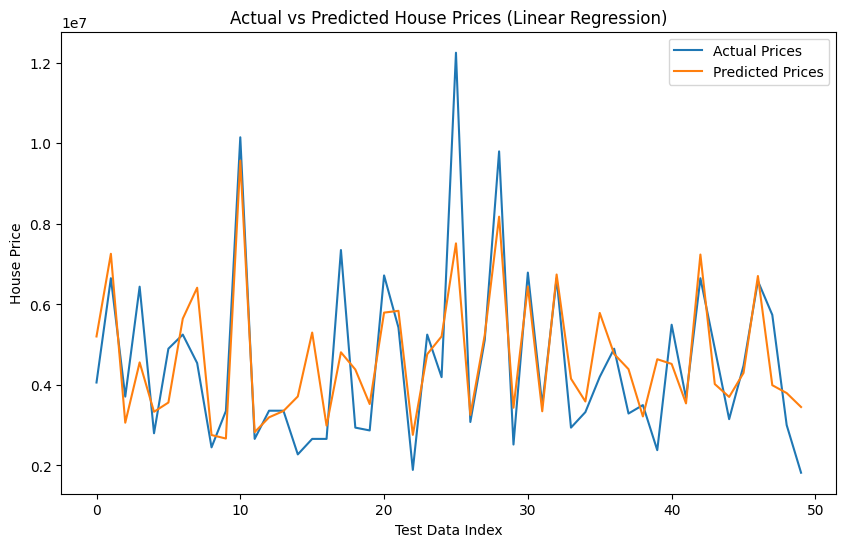

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:50], label='Actual Prices')
plt.plot(y_pred_lr[:50], label='Predicted Prices')
plt.title('Actual vs Predicted House Prices (Linear Regression)')
plt.xlabel('Test Data Index')
plt.ylabel('House Price')
plt.legend()

plt.show()

Evaluating the performance of the Linear Regression model bu using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE).
MAE measures the average prediction error and RMSE gives higher importance to larger errors.
Lower values of MAE and RMSE indicate better prediction accuracy and improved model performance.

So after evaluation, i observed by result that the Linear Regression model achieved a Mean Absolute Error (MAE) of approximately 979,679 and a Root Mean Square Error (RMSE) of approximately 1,331,071.
These evaluation metrics indicate that the model was able to predict house prices with reasonable accuracy. The RMSE value being higher than MAE suggests the presence of some larger prediction errors, which is common in real estate datasets due to price variability and complex housing patterns.
So overall model demonstrated satisfactory performance for a basic regression approach

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 979679.6912959907
Linear Regression RMSE: 1331071.4167895124


For camparing and testing, training a Gradient Booster

Training a Gradient Boosting Regressor as an advanced ensemble learning model for performance comparison. Gradient Boosting combines multiple weak decision trees to improve prediction accuracy and handle complex relationships within the data

In [ ]:
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


Predictions is generated using the Gradient Boosting model and evaluated using MAE and RMSE metrics.

In [ ]:
y_pred_gb = gb_model.predict(X_test)

gb_predictions = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_gb
})

gb_predictions.head()

,Actual Price,Predicted Price
0,4060000,4.549951e+06
1,6650000,7.319875e+06
2,3710000,3.709740e+06
3,6440000,4.364304e+06
4,2800000,3.720826e+06


In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting MAE: 964058.8730464154
Gradient Boosting RMSE: 1301871.871671099


After training both models, i compared their performances using MAE and RMSE metrics.
The Gradient Boosting model got lower error values than Linear Regression, which means its predictions were closer to the actual house prices.
So based on the evaluation results, Gradient Boosting performed better for this dataset.

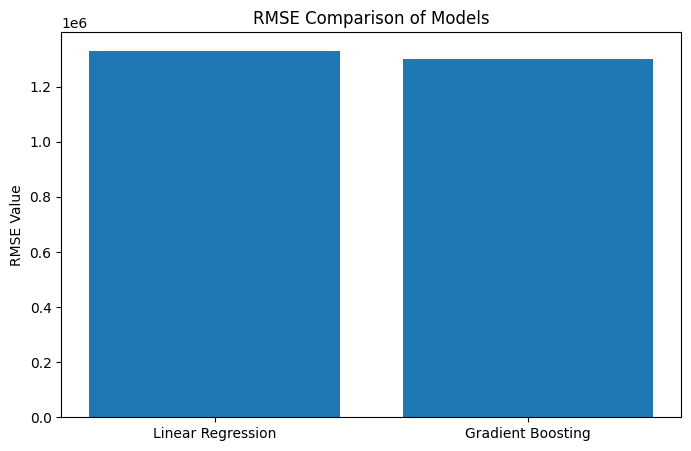

In [ ]:
models = ['Linear Regression', 'Gradient Boosting']
rmse_values = [rmse_lr, rmse_gb]

plt.figure(figsize=(8,5))

plt.bar(models, rmse_values)

plt.title('RMSE Comparison of Models')
plt.ylabel('RMSE Value')

plt.show()

The above comparison graph compares the RMSE values of both the Linear Regression and Gradient Boosting models. As the Gradient Boosting model achieved a lower RMSE value, so it indicates better prediction accuracy and lower overall prediction error.
So Gradient Boosting performed better for the house price prediction task.

Saving

In [ ]:
import joblib

joblib.dump(
    lr_model,
    '/content/drive/MyDrive/Linear Regression model houseprediction.pkl'
)

joblib.dump(
    gb_model,
    '/content/drive/MyDrive/Gradient Boosting houseprediction.pkl'
)

print("Both models saved successfully in Google Drive!")

Both models saved successfully in Google Drive!
